# SPK Rekomendasi Sekolah — K-Means + Genetic Algorithm

## Cell 1 — Install & Import Library

In [1]:
# Install dependencies (VS Code/Jupyter-friendly)
try:
    import openpyxl  # noqa: F401
    import ipywidgets as widgets  # noqa: F401
except Exception:
    # Prefer %pip inside notebooks to keep kernel state consistent
    # If this fails, run manually in a terminal: pip install openpyxl ipywidgets
    get_ipython().run_line_magic('pip', 'install openpyxl ipywidgets --quiet')

import io
import os, pickle, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score

warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)

# Nama kolom dataset
COL_SEKOLAH = 'SEKOLAH'
COL_KOTA    = 'KOTA_SEKOLAH'
COL_PROV    = 'PROP_SEKOLAH'
COL_IPK     = 'IPK'
COL_PRODI   = 'PROGRAM_STUDI'
COL_JURUSAN = 'JURUSAN'           # jurusan mahasiswa di Polinema
COL_JURSK   = 'JURUSAN_SEKOLAH'   # jurusan di sekolah asal
COL_STATUS  = 'STATUS'
COL_NPSN    = 'NPSN'
COL_P1      = 'PRESTASI_1'        # peringkat juara: 1/2/3
COL_P2      = 'PRESTASI_2'        # tingkat: 1=sekolah .. 5=internasional

KOLOM_WAJIB = [COL_SEKOLAH, COL_KOTA, COL_PROV, COL_IPK, COL_PRODI]

# Aturan klasifikasi akademik
# Kata kunci pada COL_JURUSAN (jurusan mahasiswa di Polinema)
# Jika mengandung salah satu kata ini -> prestasi = AKADEMIK
AKADEMIK_KEYWORDS = [
    'TEKNIK', 'MIPA', 'IPA', 'IPS', 'BAHASA',
    'SAINS', 'MATEMATIKA', 'FISIKA', 'KIMIA', 'BIOLOGI'
 ]
# Semua jurusan SMA (mengandung 'SMA' di COL_JURSK) -> AKADEMIK
# SMK yang tidak mengandung keyword di atas -> NON-AKADEMIK

LABEL_COLOR = {'A': '#27ae60', 'B': '#2980b9', 'C': '#c0392b'}
LABEL_DESC  = {'A': 'Unggulan', 'B': 'Menengah', 'C': 'Perlu Perhatian'}

STATE = {
    'df_raw'         : None,
    'df_clean'       : None,
    'hasil_per_prodi': {},
    'df_result_all'  : None,
    'ga_log'         : {},
}

print('Library berhasil diimport.')
print('Kolom wajib      :', KOLOM_WAJIB)
print('Keyword akademik :', AKADEMIK_KEYWORDS)
print('Lanjut ke Cell 2.')


Library berhasil diimport.
Kolom wajib      : ['SEKOLAH', 'KOTA_SEKOLAH', 'PROP_SEKOLAH', 'IPK', 'PROGRAM_STUDI']
Keyword akademik : ['TEKNIK', 'MIPA', 'IPA', 'IPS', 'BAHASA', 'SAINS', 'MATEMATIKA', 'FISIKA', 'KIMIA', 'BIOLOGI']
Lanjut ke Cell 2.


## Cell 2 — Ambil File Excel dari Google Drive

In [2]:
print('Ambil file Excel (.xlsx) dari Google Drive ...')
print('Kolom WAJIB   :', KOLOM_WAJIB)
print('Kolom prestasi: PRESTASI_1 (juara: 1/2/3), PRESTASI_2 (tingkat: 1-5)')
print()

DRIVE_URL = 'https://docs.google.com/spreadsheets/d/1fX-ma_OoNDOX7XI2_diTu16f97P4WKu_/edit?usp=sharing'

out_upload = widgets.Output()
display(out_upload)

def _read_excel_bytes(filename, content):
    try:
        df = pd.read_excel(io.BytesIO(content))

        df.columns = (
            df.columns
            .str.strip()
            .str.upper()
            .str.replace(' ', '_')
        )

        missing = [c for c in KOLOM_WAJIB if c not in df.columns]

        if missing:
            print(f'{filename} tidak memiliki kolom wajib: {missing}')
            print('Kolom tersedia:', list(df.columns))
            return None

        return df

    except Exception as e:
        print('Gagal membaca file Excel:', e)
        return None


def _drive_to_direct(url):
    import re

    url = url.strip()

    if 'export?format=xlsx' in url:
        return url

    m = re.search(r'/spreadsheets/d/([a-zA-Z0-9_-]+)', url)

    if m:
        file_id = m.group(1)
        return f'https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx'

    m = re.search(r'/d/([a-zA-Z0-9_-]+)', url)

    if not m:
        m = re.search(r'id=([a-zA-Z0-9_-]+)', url)

    if m:
        file_id = m.group(1)
        return f'https://drive.google.com/uc?export=download&id={file_id}'

    return url


def _load_from_url():
    with out_upload:
        clear_output(wait=True)

        url = DRIVE_URL.strip()

        if not url:
            print('DRIVE_URL masih kosong.')
            return

        try:
            import urllib.request

            direct_url = _drive_to_direct(url)

            print('Mengambil file dari:')
            print(direct_url)
            print()

            with urllib.request.urlopen(direct_url) as resp:
                content = resp.read()

            df = _read_excel_bytes(url, content)

            if df is None:
                return

            STATE['df_raw'] = df

            print('Load data berhasil.')
            print('Total baris :', df.shape[0])
            print('Total kolom :', df.shape[1])
            print()

            display(df.head(3))

            print('Lanjut ke Cell 3.')

        except Exception as e:
            print('Gagal membaca dari URL:')
            print(e)
            print()
            print('Pastikan:')
            print('- Link dapat diakses publik')
            print('- File berformat .xlsx atau Google Sheets')
            print('- Internet aktif')


_load_from_url()

Ambil file Excel (.xlsx) dari Google Drive ...
Kolom WAJIB   : ['SEKOLAH', 'KOTA_SEKOLAH', 'PROP_SEKOLAH', 'IPK', 'PROGRAM_STUDI']
Kolom prestasi: PRESTASI_1 (juara: 1/2/3), PRESTASI_2 (tingkat: 1-5)



Output()

## Cell 2b — Parser Prestasi Teks Bebas → PRESTASI_1 & PRESTASI_2

**Jalankan cell ini SEBELUM Cell 3 jika kolom prestasi Anda berisi teks bebas**
(contoh: `JUARA 1 LOMBA TARTIL AL-QUR'AN TINGKAT SEKOLAH`)

Cell ini secara otomatis mengekstrak:
- `PRESTASI_1` — peringkat juara: 1=Juara1, 2=Juara2, 3=Juara3
- `PRESTASI_2` — tingkat kompetisi: 1=Sekolah, 2=Kab/Kota, 3=Provinsi, 4=Nasional, 5=Internasional


In [3]:
# Cell 2b - Parser Prestasi Teks Bebas -> PRESTASI_1 & PRESTASI_2
# Kolom PRESTASI_1 di Excel berisi teks -> cell ini mengekstrak angka.
# Jalankan SETELAH Cell 2 (upload) dan SEBELUM Cell 3 (preprocessing)
import re

def parse_prestasi_teks(teks):
    """Ekstrak (PRESTASI_1, PRESTASI_2) dari teks prestasi bebas.
    PRESTASI_1: 1=Juara1, 2=Juara2, 3=Juara3, 0=tidak ada
    PRESTASI_2: 1=Sekolah, 2=Kab/Kota, 3=Provinsi, 4=Nasional, 5=Internasional
    """
    if pd.isna(teks) or str(teks).strip() in ['', '0', 'NAN', 'NONE', '-', '- - TINGKAT -']:
        return 0, 0
    t = str(teks).upper().strip()

    # PARTISIPAN/PESERTA -> tidak ada prestasi
    if re.search(r'\bPARTISIPAN\b|\bPESERTA\b', t):
        return 0, 0

    # Deteksi tingkat: cari semua frase 'TINGKAT X', ambil tertinggi
    pola_tingkat_map = [
        (r'TINGKAT\s+(INTERNASIONAL|INTERNATIONAL)', 5),
        (r'TINGKAT\s+NASIONAL', 4),
        (r'TINGKAT\s+(PROVINSI|PROPINSI|KERASIDENAN|KARESIDENAN|KORWIL|REGIONAL)', 3),
        (r'TINGKAT\s+(KABUPATEN\s*[/&]?\s*KOTA|KABUPATEN|KOTA\s*[/]\s*KAB|KAB\.?\s*KOTA|KOTA\s+KABUPATEN)', 2),
        (r'TINGKAT\s+KOTA\b', 2),
        (r'TINGKAT\s+KAB\.?\b', 2),
        (r'TINGKAT\s+(SEKOLAH|SMA|SMK)', 1),
    ]
    tingkat_candidates = [v for pola, v in pola_tingkat_map if re.search(pola, t)]
    if re.search(r'SE[\s-]?KABUPATEN|SE[\s-]?KOTA\b', t):
        tingkat_candidates.append(2)
    tingkat = max(tingkat_candidates) if tingkat_candidates else 0

    if tingkat == 0:
        if re.search(r'INTERNASIONAL|INTERNATIONAL|ASEAN|\bASIA\b|WORLD|GLOBAL|DUNIA', t): tingkat = 5
        elif re.search(r'\bNASIONAL\b|NATIONAL|\bINDONESIA\b|PERGURUAN\s+TINGGI|NUSANTARA', t): tingkat = 4
        elif re.search(r'KERASIDENAN|KARESIDENAN|KORWIL', t): tingkat = 3
        elif re.search(r'REGIONAL\b', t): tingkat = 3
        elif re.search(r'SE[\s-]?KABUPATEN|SE[\s-]?KOTA\b|\bKABUPATEN\b|\bKOTAMADYA\b', t): tingkat = 2
        elif re.search(r'\bKAB\.?\b', t): tingkat = 2
        elif re.search(r'\bSEKOLAH\b|\bSMA\b|\bSMK\b', t): tingkat = 1

    # Deteksi peringkat juara
    juara = 0
    pola_juara = [
        (r'JUARA\s*(KE)?[-\u2013\s]?1(?![0-9])',        1),
        (r'JUARA\s*(KE)?[-\u2013\s]?I(?!I|[A-Z])',      1),
        (r'JUARA\s+(SATU|PERTAMA)\b',                    1),
        (r'JUARA\s*(KE)?[-\u2013\s]?2(?![0-9])',        2),
        (r'JUARA\s*(KE)?[-\u2013\s]?II(?!I)',           2),
        (r'JUARA\s+(DUA|KEDUA)\b',                       2),
        (r'JUARA\s*(KE)?[-\u2013\s]?3(?![0-9])',        3),
        (r'JUARA\s*(KE)?[-\u2013\s]?III\b',            3),
        (r'JUARA\s+(TIGA|KETIGA)\b',                     3),
        (r'JUARA\s*(KE)?[-\u2013\s]?[456789]\b',       -1),
        (r'JUARA\s+HARAPAN',                              3),
        (r'JUARA\s+UMUM',                                 1),
        (r'3RD\s+RUNNER\s*UP',                           3),
        (r'2ND\s+RUNNER\s*UP',                           3),
        (r'1ST\s+RUNNER\s*UP',                           2),
        (r'\bRUNNER\s*UP\b',                            2),
        (r'PEMENANG\s+(1|I|SATU|PERTAMA)\b',             1),
        (r'PEMENANG\s+(2|II|DUA|KEDUA)\b',               2),
        (r'PEMENANG\s+(3|III|TIGA|KETIGA)\b',            3),
        (r'MEDALI\s+(EMAS|GOLD)',                          1),
        (r'MEDALI\s+(PERAK|SILVER)',                       2),
        (r'MEDALI\s+(PERUNGGU|BRONZE)',                    3),
        (r'BEST\s+(PAPER|POSTER|SPEAKER|TEAM|STUDENT|STRATEGY)', 1),
        (r'\bFINALIS\b',                                 3),
        (r'\bMULA\s+3\b',                               3),
    ]
    for pola, rank in pola_juara:
        if re.search(pola, t):
            juara = rank
            break

    if juara == -1:
        return 0, 0

    if juara == 0 and 'JUARA' in t:
        m = re.search(r'JUARA\s*(\d+)', t)
        if m:
            n = int(m.group(1))
            juara = n if n in (1, 2, 3) else 0
        else:
            juara = 1

    if juara == 0:
        m = re.match(r'^(\d)\s+\w', t)
        if m and int(m.group(1)) in (1, 2, 3):
            juara = int(m.group(1))

    if juara == 0:
        return 0, 0

    return juara, (tingkat if tingkat > 0 else 1)


if STATE['df_raw'] is None:
    print('Jalankan Cell 2 (upload) terlebih dahulu.')
else:
    df_tmp = STATE['df_raw'].copy()
    COL_TEKS = 'PRESTASI_1'

    if COL_TEKS not in df_tmp.columns:
        print('Kolom', COL_TEKS, 'tidak ditemukan!')
        print('Kolom yang ada:', list(df_tmp.columns))
    else:
        teks_asli = df_tmp[COL_TEKS].astype(str)
        mask_ada  = ~teks_asli.str.strip().isin(['', '0', 'NAN', 'NONE', '-', '- - TINGKAT -', 'NAN'])
        n_teks    = mask_ada.sum()
        print('Baris dengan teks prestasi:', n_teks, 'dari', len(df_tmp), 'total')

        parsed = teks_asli.apply(parse_prestasi_teks)
        df_tmp['PRESTASI_1'] = [p[0] for p in parsed]
        df_tmp['PRESTASI_2'] = [p[1] for p in parsed]

        n_ada  = (df_tmp['PRESTASI_1'] > 0).sum()
        n_miss = n_teks - n_ada

        print()
        print('Hasil parsing:')
        print('  Berhasil diparsing :', n_ada, '(' + str(round(n_ada/len(df_tmp)*100, 1)) + '%)')
        print('  Teks ada tapi miss :', n_miss, '(kemungkinan Juara 4+, Partisipan, atau format baru)')
        print('  Distribusi PRESTASI_1 :', dict(sorted(df_tmp['PRESTASI_1'].value_counts().items())))
        print('  Distribusi PRESTASI_2 :', dict(sorted(df_tmp['PRESTASI_2'].value_counts().items())))

        _preview_df = pd.DataFrame({'TEKS_ASLI': teks_asli, 'P1': df_tmp['PRESTASI_1'], 'P2': df_tmp['PRESTASI_2']})
        berhasil = _preview_df[_preview_df['P1'] > 0].head(10)
        if len(berhasil):
            print()
            print('Contoh BERHASIL diparsing:')
            display(berhasil.reset_index(drop=True))

        gagal = _preview_df[(df_tmp['PRESTASI_1'] == 0) & mask_ada]
        if len(gagal):
            print()
            print('Teks yang tidak terdeteksi (' + str(len(gagal)) + ' baris - sample):')
            display(gagal[['TEKS_ASLI']].drop_duplicates().head(10).reset_index(drop=True))
            print('Jika pola penting terlewat, tambahkan ke pola_juara atau pola_tingkat_map.')

        STATE['df_raw'] = df_tmp
        print()
        print('STATE["df_raw"] diperbarui - PRESTASI_1 & PRESTASI_2 sekarang berisi angka.')
        print('Lanjut ke Cell 3 (preprocessing).')


Baris dengan teks prestasi: 14165 dari 14224 total

Hasil parsing:
  Berhasil diparsing : 1778 (12.5%)
  Teks ada tapi miss : 12387 (kemungkinan Juara 4+, Partisipan, atau format baru)
  Distribusi PRESTASI_1 : {0: 12446, 1: 700, 2: 513, 3: 565}
  Distribusi PRESTASI_2 : {0: 12446, 1: 714, 2: 459, 3: 210, 4: 367, 5: 28}

Contoh BERHASIL diparsing:


,TEKS_ASLI,P1,P2
0,JUARA 2 FESTIVAL FUTSAL LINTAS JAWA TIMUR 2024...,2,1
1,JUARA 2 INDONESIA INTERNASIONAL TAEKWONDO CHAM...,2,5
2,"JUARA 1 LIGA KACABDIN ""FREE FIRE"" SE KABUPATEN...",1,2
3,JUARA 1 LOMBA TARTIL AL-QUR'AN TINGKAT SEKOLAH,1,1
4,JUARA 3 GASMI CUP TINGKAT KERASIDENAN KEDIRI,3,3
5,JUARA 2 TURNAMENT MOBILE LEGEND AL QOLAM TINGK...,2,1
6,JUARA 1 GARENA YOUTH CHAMPIONSHIP TINGKAT SEKOLAH,1,1
7,MULA 3 LKBB TINGKAT PROVINSI,3,3
8,JUARA 2 TINGKAT KOTA BASKET JUNIOR TINGKAT SEK...,2,2
9,3RD RUNNER UP ASEC SPEECH COMPETITION TINGKAT ...,3,4



Teks yang tidak terdeteksi (12387 baris - sample):


,TEKS_ASLI
0,nan
1,JUARA 4 FUTSAL TOURNAMENT POCARI SWEAT PIALA P...
2,PARTISIPAN NECESA 2.0 TINGKAT NASIONAL
3,14 ALBANJARI TINGKAT PROVINSI JATIM
4,SEMIFINAL ELECTRA ITS TINGKAT NASIONAL
5,PARTISIPAN PEMBINAAN MENTAL DAN FISIK TINGKAT ...
6,4 KSM TINGKAT KABUPATEN
7,GOLD MEDAL YOUTH NATIONAL SCIENCE FAIR 2024 TI...
8,WAKIL KETUA OSIS KETUA 2 OSIS SMA NEGERI 2 MAL...
9,PESERTA NATIONAL LINE FOLLOWER ROBOT CONTEST K...


Jika pola penting terlewat, tambahkan ke pola_juara atau pola_tingkat_map.

STATE["df_raw"] diperbarui - PRESTASI_1 & PRESTASI_2 sekarang berisi angka.
Lanjut ke Cell 3 (preprocessing).


## Cell 3 — Preprocessing + Rekayasa Fitur Prestasi

> **Pastikan Cell 2b sudah dijalankan** sebelum Cell 3 jika data prestasi Anda berupa teks bebas!

**Fitur prestasi yang dibuat per mahasiswa:**
- `skor_juara` — nilai terbalik juara: Juara1=3, Juara2=2, Juara3=1, tidak ada=0
- `skor_tingkat` — nilai tingkat: Internasional=5, Nasional=4, dst
- `is_akademik` — 1 jika jurusan mengandung keyword akademik, 0 jika tidak

**Fitur agregat per sekolah (untuk clustering):**
- `rata_juara` — rata-rata skor juara mahasiswa dari sekolah itu
- `rata_tingkat` — rata-rata skor tingkat
- `jml_prestasi_akademik` — total mahasiswa berprestasi akademik
- `jml_prestasi_nonakademik` — total mahasiswa berprestasi non-akademik


Sebelum preprocessing:
  Total baris : 14224
  Null (wajib): {'SEKOLAH': 0, 'KOTA_SEKOLAH': 0, 'PROP_SEKOLAH': 0, 'IPK': 0, 'PROGRAM_STUDI': 0}

Setelah preprocessing & rekayasa fitur:
  Baris tersisa         : 13645
  Sekolah unik          : 2007
  Program Studi         : 38 prodi

  Ringkasan Prestasi:
  Mahasiswa berprestasi : 1772 (13.0%)
  Prestasi Akademik     : 949
  Prestasi Non-Akademik : 823


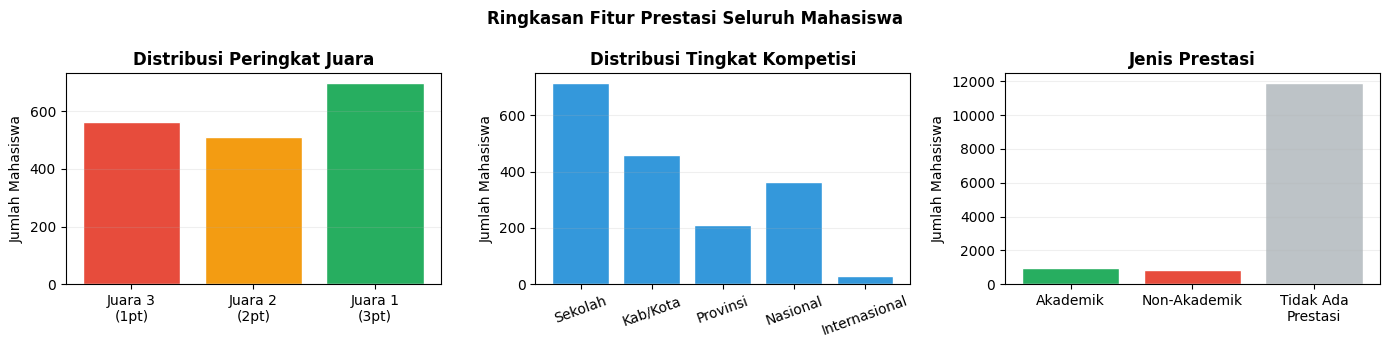

Rekayasa fitur selesai. Lanjut ke Cell 4.


In [4]:
if STATE['df_raw'] is None:
    print('Jalankan Cell 2 terlebih dahulu.')
else:
    df = STATE['df_raw'].copy()

    print('Sebelum preprocessing:')
    print('  Total baris :', df.shape[0])
    print('  Null (wajib):', df[KOLOM_WAJIB].isnull().sum().to_dict())

    # 1. Bersihkan data dasar
    df = df.dropna(subset=KOLOM_WAJIB).drop_duplicates().reset_index(drop=True)

    df[COL_IPK] = pd.to_numeric(
        df[COL_IPK].astype(str).str.replace(',', '.', regex=False).str.strip(),
        errors='coerce'
    )
    df = df.dropna(subset=[COL_IPK])
    df = df[(df[COL_IPK] >= 0.0) & (df[COL_IPK] <= 4.0)]

    for col in [COL_SEKOLAH, COL_KOTA, COL_PROV, COL_PRODI]:
        df[col] = df[col].astype(str).str.strip().str.upper()
    for col in [COL_JURUSAN, COL_JURSK, COL_STATUS]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.upper()

    # 2. Konversi PRESTASI_1 (juara) dan PRESTASI_2 (tingkat)
    for col in [COL_P1, COL_P2]:
        if col in df.columns:
            df[col] = pd.to_numeric(
                df[col].astype(str).str.replace(',', '.', regex=False),
                errors='coerce'
            ).fillna(0)

    # 3. Rekayasa fitur: skor_juara
    #    PRESTASI_1: 1=Juara1, 2=Juara2, 3=Juara3, 0=tidak ada
    #    Dibalik: Juara1 -> 3 poin, Juara2 -> 2, Juara3 -> 1, 0 -> 0
    if COL_P1 in df.columns:
        juara_map = {1: 3, 2: 2, 3: 1, 0: 0}
        df['skor_juara'] = df[COL_P1].map(juara_map).fillna(0)
    else:
        df['skor_juara'] = 0
        print('Kolom PRESTASI_1 tidak ditemukan, skor_juara = 0')

    # 4. Rekayasa fitur: skor_tingkat
    #    PRESTASI_2: 1=sekolah, 2=kab/kota, 3=provinsi, 4=nasional, 5=internasional
    if COL_P2 in df.columns:
        df['skor_tingkat'] = df[COL_P2].clip(0, 5)
    else:
        df['skor_tingkat'] = 0
        print('Kolom PRESTASI_2 tidak ditemukan, skor_tingkat = 0')

    # 5. Rekayasa fitur: is_akademik
    def classify_akademik(row):
        jurusan_polinema = str(row.get(COL_JURUSAN, '')).upper()
        jursk = str(row.get(COL_JURSK, '')).upper()
        if 'SMA' in jursk or 'MA ' in jursk:
            return 1
        for kw in AKADEMIK_KEYWORDS:
            if kw in jurusan_polinema:
                return 1
        return 0

    if COL_JURUSAN in df.columns or COL_JURSK in df.columns:
        df['is_akademik'] = df.apply(classify_akademik, axis=1)
    else:
        df['is_akademik'] = 1
        print('Kolom JURUSAN/JURUSAN_SEKOLAH tidak ditemukan, is_akademik = 1 (semua)')

    # 6. Tandai mahasiswa yang punya prestasi
    df['punya_prestasi']       = (df['skor_juara'] > 0).astype(int)
    df['prestasi_akademik']    = ((df['punya_prestasi'] == 1) & (df['is_akademik'] == 1)).astype(int)
    df['prestasi_nonakademik'] = ((df['punya_prestasi'] == 1) & (df['is_akademik'] == 0)).astype(int)

    df = df.reset_index(drop=True)
    STATE['df_clean'] = df

    n_prestasi    = (df['punya_prestasi'] == 1).sum()
    n_akademik    = df['prestasi_akademik'].sum()
    n_nonakademik = df['prestasi_nonakademik'].sum()

    print()
    print('Setelah preprocessing & rekayasa fitur:')
    print('  Baris tersisa         :', df.shape[0])
    print('  Sekolah unik          :', df[COL_SEKOLAH].nunique())
    print('  Program Studi         :', df[COL_PRODI].nunique(), 'prodi')
    print()
    print('  Ringkasan Prestasi:')
    print('  Mahasiswa berprestasi :', n_prestasi, '(' + str(round(n_prestasi/df.shape[0]*100, 1)) + '%)')
    print('  Prestasi Akademik     :', n_akademik)
    print('  Prestasi Non-Akademik :', n_nonakademik)

    fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

    juara_dist = df[df['skor_juara'] > 0]['skor_juara'].value_counts().sort_index()
    axes[0].bar(['Juara 3\n(1pt)', 'Juara 2\n(2pt)', 'Juara 1\n(3pt)'],
                [juara_dist.get(1, 0), juara_dist.get(2, 0), juara_dist.get(3, 0)],
                color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='white')
    axes[0].set_title('Distribusi Peringkat Juara', fontweight='bold')
    axes[0].set_ylabel('Jumlah Mahasiswa')
    axes[0].grid(True, alpha=0.2, axis='y')

    tingkat_lbl = ['Sekolah', 'Kab/Kota', 'Provinsi', 'Nasional', 'Internasional']
    tingkat_val = [df[df['skor_tingkat'] == i].shape[0] for i in range(1, 6)]
    axes[1].bar(tingkat_lbl, tingkat_val, color='#3498db', edgecolor='white')
    axes[1].set_title('Distribusi Tingkat Kompetisi', fontweight='bold')
    axes[1].set_ylabel('Jumlah Mahasiswa')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].grid(True, alpha=0.2, axis='y')

    axes[2].bar(['Akademik', 'Non-Akademik', 'Tidak Ada\nPrestasi'],
                [n_akademik, n_nonakademik, df.shape[0] - n_prestasi],
                color=['#27ae60', '#e74c3c', '#bdc3c7'], edgecolor='white')
    axes[2].set_title('Jenis Prestasi', fontweight='bold')
    axes[2].set_ylabel('Jumlah Mahasiswa')
    axes[2].grid(True, alpha=0.2, axis='y')

    plt.suptitle('Ringkasan Fitur Prestasi Seluruh Mahasiswa', fontweight='bold')
    plt.tight_layout()
    plt.show()

    print('Rekayasa fitur selesai. Lanjut ke Cell 4.')


## Cell 4 — GA + K-Means per Prodi (Prestasi = Penunjang)

**Arsitektur Baru:**
- Prestasi **TIDAK** masuk ke dalam fitur K-Means
- K-Means hanya memakai 3 fitur murni akademik: `mahasiswa`, `ipk_mean`, `ipk_std`
- Setelah cluster terbentuk, skor prestasi dihitung per cluster sebagai **penunjang** ranking
- Label A/B/C diberikan **dinamis per prodi** setelah clustering

**Kromosom GA (5 gen):**
```
[ K | w_mhs | w_ipk_mean | w_ipk_std | w_prestasi ]
```
1. `mahasiswa` — jumlah mahasiswa dari sekolah di prodi ini
2. `ipk_mean` — rata-rata IPK
3. `ipk_std` — standar deviasi IPK (konsistensi)
4. `skor_prestasi` — skor prestasi gabungan (hanya untuk ranking cluster, bukan clustering)

In [5]:
if STATE['df_clean'] is None:
    print('Jalankan Cell 3 terlebih dahulu.')
else:
    # KONFIGURASI
    K_MIN          = 2
    K_MAX          = 8
    MIN_SEKOLAH    = 5
    MIN_UNIQUE_PT  = 4
    RANDOM_STATE   = 42
    POP_SIZE       = 20
    N_GEN          = 30
    CROSSOVER_RATE = 0.8
    MUTATION_RATE  = 0.2
    TOURNAMENT_K   = 3
    ELITISM        = 2

    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)

    df         = STATE['df_clean'].copy()
    prodi_list = sorted(df[COL_PRODI].unique())

    # Fitur clustering: hanya 3 fitur murni (tanpa prestasi)
    FITUR_CLUSTER = ['mahasiswa', 'ipk_mean', 'ipk_std']
    N_BOBOT       = len(FITUR_CLUSTER)  # = 3

    def _norm(s):
        mn, mx = s.min(), s.max()
        return (s - mn) / (mx - mn) if mx != mn else pd.Series(0.5, index=s.index)

    def agregasi_sekolah(df_prodi):
        df_sk = df_prodi.groupby(COL_SEKOLAH).agg(
            mahasiswa                = (COL_IPK,              'count'),
            ipk_mean                 = (COL_IPK,              'mean'),
            ipk_std                  = (COL_IPK,              'std'),
            rata_juara               = ('skor_juara',         'mean'),
            rata_tingkat             = ('skor_tingkat',       'mean'),
            jml_prestasi_akademik    = ('prestasi_akademik',  'sum'),
            jml_prestasi_nonakademik = ('prestasi_nonakademik', 'sum'),
        ).fillna(0).reset_index()
        df_sk['skor_prestasi'] = df_sk['rata_juara'] * df_sk['rata_tingkat']
        return df_sk

    def _no_variance(s):
        s = s.dropna()
        if s.empty:
            return True
        return s.nunique() <= 1 or float(s.std()) == 0.0

    # Genetic Algorithm
    # Kromosom: [K, w_mhs, w_ipk_mean, w_ipk_std]
    def init_chromosome():
        k = random.randint(K_MIN, K_MAX)
        w = np.random.dirichlet(np.ones(N_BOBOT))
        return [float(k)] + list(w)

    def decode(chrom):
        k       = max(K_MIN, min(K_MAX, int(round(chrom[0]))))
        weights = np.array(chrom[1:N_BOBOT + 1])
        weights = np.clip(weights, 1e-6, None)
        weights = weights / weights.sum()
        return k, weights

    def fitness_fn(chrom, df_sk, scaler):
        """Fitness: Davies-Bouldin Index pada FITUR_CLUSTER saja."""
        k, _ = decode(chrom)
        k    = min(k, df_sk.shape[0] - 1)
        if k < 2:
            return 999.0, None, None
        X_sc = scaler.transform(df_sk[FITUR_CLUSTER].values)
        try:
            km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            labels = km.fit_predict(X_sc)
            if len(np.unique(labels)) < 2:
                return 999.0, None, None
            dbi = davies_bouldin_score(X_sc, labels)
            return dbi, km, labels
        except Exception:
            return 999.0, None, None

    def tournament_sel(pop, scores):
        idx      = random.sample(range(len(pop)), TOURNAMENT_K)
        best_idx = min(idx, key=lambda i: scores[i])
        return pop[best_idx][:]

    def crossover(p1, p2):
        if random.random() > CROSSOVER_RATE:
            return p1[:], p2[:]
        a  = random.random()
        c1 = [a * p1[i] + (1 - a) * p2[i] for i in range(len(p1))]
        c2 = [(1 - a) * p1[i] + a * p2[i] for i in range(len(p1))]
        c1[0] = round(c1[0])
        c2[0] = round(c2[0])
        return c1, c2

    def mutate(chrom):
        chrom = chrom[:]
        if random.random() < MUTATION_RATE:
            chrom[0] = chrom[0] + random.choice([-1, 0, 1])
            chrom[0] = max(K_MIN, min(K_MAX, round(chrom[0])))
        for i in range(1, N_BOBOT + 1):
            if random.random() < MUTATION_RATE:
                chrom[i] = abs(chrom[i] + np.random.normal(0, 0.1))
        return chrom

    def run_ga(df_sk):
        scaler     = StandardScaler().fit(df_sk[FITUR_CLUSTER].values)
        population = [init_chromosome() for _ in range(POP_SIZE)]
        log_best, log_avg = [], []
        best_chrom, best_score = None, 999.0

        for gen in range(N_GEN):
            scores = [fitness_fn(c, df_sk, scaler)[0] for c in population]

            gen_best_idx = int(np.argmin(scores))
            if scores[gen_best_idx] < best_score:
                best_score = scores[gen_best_idx]
                best_chrom = population[gen_best_idx][:]

            log_best.append(best_score)
            valid_scores = [s for s in scores if s < 999]
            log_avg.append(float(np.mean(valid_scores)) if valid_scores else 999.0)

            sorted_idx = sorted(range(len(scores)), key=lambda i: scores[i])
            elites     = [population[i][:] for i in sorted_idx[:ELITISM]]
            new_pop    = elites[:]

            while len(new_pop) < POP_SIZE:
                p1, p2 = tournament_sel(population, scores), tournament_sel(population, scores)
                c1, c2 = crossover(p1, p2)
                new_pop.append(mutate(c1))
                if len(new_pop) < POP_SIZE:
                    new_pop.append(mutate(c2))

            population = new_pop

        if best_chrom is None:
            best_chrom = [3.0] + [1 / N_BOBOT] * N_BOBOT
            best_score = 999.0

        return best_chrom, best_score, {'best': log_best, 'avg': log_avg}

    # Ranking cluster - Label Dinamis per Prodi
    RANK_W_IPK      = 0.50
    RANK_W_STD      = 0.20
    RANK_W_PRESTASI = 0.30

    def ranking_cluster_dinamis(df_sk, cs, weights):
        cs = cs.copy()

        def safe_norm(s):
            mn, mx = s.min(), s.max()
            if mx == mn:
                return pd.Series(0.5, index=s.index)
            return (s - mn) / (mx - mn)

        cs['norm_ipk']      = safe_norm(cs['ipk_mean'])
        cs['norm_std_inv']  = 1 - safe_norm(cs['ipk_std'])
        cs['norm_prestasi'] = safe_norm(cs['skor_prestasi_cluster'])

        cs['skor_ranking'] = (
            RANK_W_IPK      * cs['norm_ipk']      +
            RANK_W_STD      * cs['norm_std_inv']  +
            RANK_W_PRESTASI * cs['norm_prestasi']
        )

        ranked_clusters = cs.sort_values('skor_ranking', ascending=False)['Cluster'].tolist()
        n_actual        = len(ranked_clusters)
        label_map = {ranked_clusters[i]: lbl
                     for i, lbl in enumerate(['A', 'B', 'C'][:n_actual])}
        return label_map, cs

    # Jalankan GA + K-Means per prodi
    hasil_per_prodi = {}
    prodi_skip      = []
    all_results     = []
    ga_log          = {}
    t_start         = time.time()

    print('GA + K-Means untuk', len(prodi_list), 'prodi')
    print('  POP=' + str(POP_SIZE) + ' | GEN=' + str(N_GEN) + ' | CR=' + str(CROSSOVER_RATE) + ' | MR=' + str(MUTATION_RATE))
    print('  Fitur clustering :', FITUR_CLUSTER, '(prestasi TIDAK termasuk)')
    print('  Kromosom         : [K, w_mhs, w_ipk_mean, w_ipk_std]')
    print('  Penunjang ranking: skor_prestasi = rata_juara x rata_tingkat')
    print('  Bobot ranking    : IPK=' + str(RANK_W_IPK) + ' | Std_inv=' + str(RANK_W_STD) + ' | Prestasi=' + str(RANK_W_PRESTASI))
    print('=' * 80)

    for idx, prodi in enumerate(prodi_list, 1):
        df_p  = df[df[COL_PRODI] == prodi].copy()
        df_sk = agregasi_sekolah(df_p)
        n_sk  = df_sk.shape[0]

        if n_sk < MIN_SEKOLAH:
            prodi_skip.append(prodi)
            print('[' + str(idx).zfill(2) + '/' + str(len(prodi_list)) + '] SKIP ' + prodi + ' (' + str(n_sk) + ' sekolah < ' + str(MIN_SEKOLAH) + ')')
            continue
        if any(_no_variance(df_sk[f]) for f in FITUR_CLUSTER):
            prodi_skip.append(prodi)
            print('[' + str(idx).zfill(2) + '/' + str(len(prodi_list)) + '] SKIP ' + prodi + ' (ada fitur tanpa variasi)')
            continue
        n_unique = df_sk[FITUR_CLUSTER].drop_duplicates().shape[0]
        if n_unique < MIN_UNIQUE_PT:
            prodi_skip.append(prodi)
            print('[' + str(idx).zfill(2) + '/' + str(len(prodi_list)) + '] SKIP ' + prodi + ' (titik unik terlalu sedikit: ' + str(n_unique) + ')')
            continue

        t0 = time.time()

        best_chrom, best_dbi, log = run_ga(df_sk)

        if best_chrom is None:
            best_chrom = [3.0] + [1 / N_BOBOT] * N_BOBOT
            best_dbi   = 999.0

        k_opt, weights = decode(best_chrom)
        k_opt = max(2, min(k_opt, n_sk - 1))

        # K-Means hanya pada 3 fitur clustering
        X      = df_sk[FITUR_CLUSTER].values
        scaler = StandardScaler()
        X_sc   = scaler.fit_transform(X)
        kmeans = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
        df_sk['Cluster'] = kmeans.fit_predict(X_sc)

        # Ringkasan per cluster
        cs = df_sk.groupby('Cluster').agg(
            total_mhs               = ('mahasiswa',               'sum'),
            ipk_mean                = ('ipk_mean',               'mean'),
            ipk_std                 = ('ipk_std',                'mean'),
            rata_juara              = ('rata_juara',             'mean'),
            rata_tingkat            = ('rata_tingkat',           'mean'),
            skor_prestasi_cluster   = ('skor_prestasi',          'mean'),
            jml_akd                 = ('jml_prestasi_akademik',  'sum'),
            jml_noakd               = ('jml_prestasi_nonakademik', 'sum'),
        ).reset_index()

        label_map, cs_ranked = ranking_cluster_dinamis(df_sk, cs, weights)
        cs['Label']    = cs['Cluster'].map(label_map)
        df_sk['Label'] = df_sk['Cluster'].map(label_map)

        cs = cs.sort_values(
            'skor_ranking' if 'skor_ranking' in cs.columns else 'ipk_mean',
            ascending=False
        ).drop_duplicates(subset='Label').reset_index(drop=True)

        df_res = df_p.merge(
            df_sk[[COL_SEKOLAH, 'Cluster', 'Label', 'mahasiswa', 'ipk_mean', 'ipk_std',
                   'rata_juara', 'rata_tingkat', 'skor_prestasi',
                   'jml_prestasi_akademik', 'jml_prestasi_nonakademik']],
            on=COL_SEKOLAH, how='left'
        )
        df_res[COL_PRODI] = prodi

        hasil_per_prodi[prodi] = {
            'df_sekolah'     : df_sk,
            'df_result'      : df_res,
            'kmeans'         : kmeans,
            'scaler'         : scaler,
            'cluster_summary': cs,
            'label_map'      : label_map,
            'n_clusters'     : k_opt,
            'best_chrom'     : best_chrom,
            'best_dbi'       : best_dbi,
            'weights'        : weights,
            'fitur_cluster'  : FITUR_CLUSTER,
        }
        ga_log[prodi] = log
        all_results.append(df_res)

        dist       = df_sk['Label'].value_counts().sort_index().to_dict()
        w          = weights
        label_info = ' | '.join(['Cluster' + str(k) + '->' + v for k, v in sorted(label_map.items())])
        elapsed    = round(time.time() - t0, 1)
        print('[' + str(idx).zfill(2) + '/' + str(len(prodi_list)) + '] ' + prodi)
        print('  K=' + str(k_opt) + ' | DBI=' + str(round(best_dbi, 4)) + ' | ' + str(elapsed) + 's')
        print('  bobot: mhs=' + str(round(w[0], 2)) + ' ipk=' + str(round(w[1], 2)) + ' std=' + str(round(w[2], 2)))
        print('  label :', label_info)
        print('  dist  :', dist)

    df_result_all = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
    STATE.update({
        'hasil_per_prodi': hasil_per_prodi,
        'df_result_all'  : df_result_all,
        'ga_log'         : ga_log,
    })

    with open('models/kmeans_ga_prestasi.pkl', 'wb') as f:
        pickle.dump(STATE, f)

    elapsed_total = round(time.time() - t_start, 1)
    print('=' * 80)
    print('Selesai! Total:', elapsed_total, 's')
    print('Berhasil:', len(hasil_per_prodi), 'prodi | Dilewati:', len(prodi_skip))
    print('Prestasi dipakai sebagai PENUNJANG, bukan fitur clustering.')
    print('Label A/B/C ditentukan dinamis per prodi.')
    print('Lanjut ke Cell 4b atau Cell 5.')


GA + K-Means untuk 38 prodi
  POP=20 | GEN=30 | CR=0.8 | MR=0.2
  Fitur clustering : ['mahasiswa', 'ipk_mean', 'ipk_std'] (prestasi TIDAK termasuk)
  Kromosom         : [K, w_mhs, w_ipk_mean, w_ipk_std]
  Penunjang ranking: skor_prestasi = rata_juara x rata_tingkat
  Bobot ranking    : IPK=0.5 | Std_inv=0.2 | Prestasi=0.3
[01/38] ADMINISTRASI BISNIS
  K=3 | DBI=0.4662 | 2.2s
  bobot: mhs=0.15 ipk=0.28 std=0.57
  label : Cluster0->A | Cluster1->B | Cluster2->C
  dist  : {'A': 137, 'B': 48, 'C': 43}
[02/38] AKUNTANSI
  K=5 | DBI=0.4424 | 3.6s
  bobot: mhs=0.51 ipk=0.01 std=0.48
  label : Cluster1->C | Cluster2->A | Cluster3->B
  dist  : {'A': 170, 'B': 2, 'C': 73}
[03/38] AKUNTANSI MANAJEMEN
  K=5 | DBI=0.4314 | 3.8s
  bobot: mhs=0.11 ipk=0.01 std=0.88
  label : Cluster0->A | Cluster2->C | Cluster3->B
  dist  : {'A': 227, 'B': 46, 'C': 73}
[04/38] BAHASA INGGRIS UNTUK INDUSTRI PARIWISATA
  K=6 | DBI=0.3348 | 2.9s
  bobot: mhs=0.19 ipk=0.26 std=0.55
  label : Cluster0->A | Cluster4->C | C

## Cell 4b — Visualisasi Konvergensi GA & Bobot per Prodi

In [6]:
if not STATE['ga_log']:
    print('Jalankan Cell 4 terlebih dahulu.')
else:
    ga_log          = STATE['ga_log']
    hasil_per_prodi = STATE['hasil_per_prodi']
    BOBOT_LABELS    = ['w_mhs', 'w_ipk_mean', 'w_ipk_std']
    BOBOT_COLORS    = ['#3498db', '#27ae60', '#e74c3c']

    w_prodi  = widgets.Dropdown(options=sorted(ga_log.keys()), description='Prodi:',
                                layout=widgets.Layout(width='400px'))
    out_conv = widgets.Output()

    def plot_konvergensi(change=None):
        with out_conv:
            clear_output(wait=True)
            prodi = w_prodi.value
            log   = ga_log[prodi]
            res   = hasil_per_prodi[prodi]
            w     = res['weights']
            k_opt = res['n_clusters']
            dbi   = res['best_dbi']
            cs    = res['cluster_summary']
            lmap  = res['label_map']

            fig, axes = plt.subplots(1, 3, figsize=(18, 4))
            fig.suptitle('Hasil GA - ' + prodi, fontweight='bold', fontsize=12)

            # Kurva konvergensi
            gens = range(1, len(log['best']) + 1)
            axes[0].plot(gens, log['best'], 'r-o', markersize=4, lw=2, label='DBI Terbaik')
            axes[0].plot(gens, log['avg'],  'b--', markersize=3, lw=1.5, label='DBI Rata-rata', alpha=0.7)
            axes[0].set_xlabel('Generasi')
            axes[0].set_ylabel('Davies-Bouldin Index')
            axes[0].set_title('Konvergensi DBI (K optimal = ' + str(k_opt) + ')')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            if log['best'][0] > 0:
                improve = (log['best'][0] - log['best'][-1]) / log['best'][0] * 100
                axes[0].set_xlabel('Generasi  |  Perbaikan: ' + str(round(improve, 1)) + '%')

            # Bar bobot 3 variabel clustering
            bars = axes[1].bar(BOBOT_LABELS, w, color=BOBOT_COLORS, edgecolor='white', width=0.5)
            axes[1].set_title('Bobot GA: 3 Fitur Clustering')
            axes[1].set_ylabel('Bobot')
            axes[1].set_ylim(0, min(1.0, max(w) * 1.3))
            for bar, val in zip(bars, w):
                axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                             str(round(val, 3)), ha='center', fontsize=10, fontweight='bold')
            axes[1].grid(True, alpha=0.2, axis='y')

            # Bar skor ranking cluster
            if 'skor_ranking' in cs.columns:
                cs_plot = cs.copy().sort_values('skor_ranking', ascending=False)
                lbls    = [lmap.get(c, 'C' + str(c)) for c in cs_plot['Cluster']]
                colors  = [LABEL_COLOR.get(l, '#95a5a6') for l in lbls]
                bars2   = axes[2].bar(lbls, cs_plot['skor_ranking'], color=colors, edgecolor='white', width=0.5)
                axes[2].set_title('Skor Ranking Cluster (IPK + Prestasi)')
                axes[2].set_ylabel('Skor Ranking')
                for bar, val in zip(bars2, cs_plot['skor_ranking']):
                    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                                 str(round(val, 3)), ha='center', fontsize=10, fontweight='bold')
                axes[2].grid(True, alpha=0.2, axis='y')
            else:
                axes[2].axis('off')
                axes[2].text(0.5, 0.5, 'Skor ranking tidak tersedia', ha='center', va='center')

            plt.tight_layout()
            plt.show()

            # Ringkasan kromosom terbaik
            label_info = ', '.join(
                ['Cluster ' + str(k) + ' -> ' + v + ' (' + LABEL_DESC.get(v, '-') + ')'
                 for k, v in sorted(lmap.items())]
            )
            print()
            print('Kromosom Terbaik -', prodi)
            print('  K (jumlah cluster)  :', k_opt)
            print('  w_mahasiswa         :', round(w[0], 4))
            print('  w_ipk_mean          :', round(w[1], 4))
            print('  w_ipk_std           :', round(w[2], 4))
            print('  Prestasi (penunjang): skor_juara x skor_tingkat (bukan fitur K-Means)')
            print('  DBI terbaik         :', round(dbi, 4), '| Generasi:', len(log['best']))
            print('  Label dinamis       :', label_info)

    w_prodi.observe(plot_konvergensi, names='value')
    display(widgets.VBox([w_prodi, out_conv]))
    plot_konvergensi()


## Cell 4c - Perbandingan DBI: K-Means Tanpa GA vs K-Means + GA

Jalankan cell ini **setelah Cell 4** selesai.

- **Tanpa GA**: K-Means K=3 tetap, bobot fitur seragam
- **Dengan GA**: K dan bobot optimal hasil Genetic Algorithm
- Prodi dengan data < 3 sekolah atau GA gagal (DBI=999) otomatis dilewati
- Semakin kecil DBI semakin baik kualitas clustering

In [7]:
if not STATE['hasil_per_prodi']:
    print('Jalankan Cell 4 terlebih dahulu.')
else:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import davies_bouldin_score

    hasil_per_prodi = STATE['hasil_per_prodi']
    FITUR_CLUSTER   = ['mahasiswa', 'ipk_mean', 'ipk_std']
    RANDOM_STATE    = 42
    rows = []

    for prodi, res in sorted(hasil_per_prodi.items()):
        df_sk   = res['df_sekolah'].copy()
        missing = [f for f in FITUR_CLUSTER if f not in df_sk.columns]
        if missing or df_sk.shape[0] < 3:
            continue

        X      = df_sk[FITUR_CLUSTER].fillna(0).values
        scaler = StandardScaler()
        X_sc   = scaler.fit_transform(X)

        # K-Means tanpa GA (K=3 tetap)
        k_default = min(3, df_sk.shape[0] - 1)
        try:
            km_default     = KMeans(n_clusters=k_default, random_state=RANDOM_STATE, n_init=10)
            labels_default = km_default.fit_predict(X_sc)
            if len(np.unique(labels_default)) >= 2:
                dbi_tanpa_ga = round(davies_bouldin_score(X_sc, labels_default), 4)
            else:
                dbi_tanpa_ga = None
        except Exception:
            dbi_tanpa_ga = None

        # K-Means dengan GA
        dbi_dengan_ga_raw = res['best_dbi']
        if dbi_dengan_ga_raw >= 99:
            continue
        dbi_dengan_ga = round(dbi_dengan_ga_raw, 4)
        k_ga          = res['n_clusters']

        if dbi_tanpa_ga is None:
            continue

        selisih = round(dbi_tanpa_ga - dbi_dengan_ga, 4)
        persen  = round((selisih / dbi_tanpa_ga) * 100, 2) if dbi_tanpa_ga > 0 else 0.0

        if selisih > 0.0001:
            ket = 'Lebih Baik'
        elif selisih > -0.0001:
            ket = 'Sama'
        else:
            ket = 'Lebih Buruk'

        rows.append({
            'Program Studi' : prodi,
            'Jml Sekolah'   : df_sk.shape[0],
            'K tanpa GA'    : k_default,
            'DBI tanpa GA'  : dbi_tanpa_ga,
            'K optimal GA'  : k_ga,
            'DBI dengan GA' : dbi_dengan_ga,
            'Selisih DBI'   : selisih,
            'Penurunan (%)'  : persen,
            'Keterangan'    : ket,
        })

    df_hasil     = pd.DataFrame(rows)
    avg_tanpa    = round(df_hasil['DBI tanpa GA'].mean(), 4)
    avg_ga       = round(df_hasil['DBI dengan GA'].mean(), 4)
    avg_persen   = round(df_hasil['Penurunan (%)'].mean(), 2)
    n_lebih_baik = (df_hasil['Keterangan'] == 'Lebih Baik').sum()
    n_sama       = (df_hasil['Keterangan'] == 'Sama').sum()
    n_buruk      = (df_hasil['Keterangan'] == 'Lebih Buruk').sum()
    n_total      = len(df_hasil)
    n_skip       = len(hasil_per_prodi) - n_total

    display(df_hasil.sort_values('DBI dengan GA').reset_index(drop=True))

    print()
    print('Perbandingan DBI - K-Means Tanpa GA vs K-Means + GA')
    print('  Rata-rata DBI Tanpa GA :', avg_tanpa)
    print('  Rata-rata DBI Dengan GA:', avg_ga)
    print('  Rata-rata Penurunan    :', str(avg_persen) + '%')
    print('  Lebih Baik:', n_lebih_baik, '| Sama:', n_sama, '| Lebih Buruk:', n_buruk)
    print('  Total prodi valid:', n_total)
    if n_skip > 0:
        print('  Dilewati (data terlalu sedikit / GA gagal):', n_skip, 'prodi')

    STATE['df_perbandingan_dbi'] = df_hasil


,Program Studi,Jml Sekolah,K tanpa GA,DBI tanpa GA,K optimal GA,DBI dengan GA,Selisih DBI,Penurunan (%),Keterangan
0,REKAYASA TEKNOLOGI INFORMASI,14,3,0.0389,8,0.0000,0.0389,100.00,Lebih Baik
1,PENGEMBANGAN PERANGKAT (PIRANTI) LUNAK SITUS,8,3,0.3682,7,0.0082,0.3600,97.77,Lebih Baik
2,TEKNOLOGI PEMELIHARAAN PESAWAT UDARA,40,3,0.2467,5,0.0922,0.1545,62.63,Lebih Baik
3,TEKNOLOGI REKAYASA OTOMOTIF,63,3,0.6487,8,0.1808,0.4679,72.13,Lebih Baik
4,TEKNOLOGI REKAYASA KONSTRUKSI JALAN DAN JEMBATAN,117,3,0.4589,4,0.2063,0.2526,55.04,Lebih Baik
5,TEKNOLOGI SIPIL,49,3,0.4294,7,0.2523,0.1771,41.24,Lebih Baik
6,USAHA PERJALANAN WISATA,138,3,0.4724,4,0.2529,0.2195,46.46,Lebih Baik
7,PENGELOLAAN ARSIP DAN REKAMAN INFORMASI,124,3,0.4020,8,0.2758,0.1262,31.39,Lebih Baik
8,TEKNOLOGI INFORMASI,70,3,0.4877,4,0.3002,0.1875,38.45,Lebih Baik
9,SISTEM INFORMASI BISNIS,326,3,0.4648,4,0.3099,0.1549,33.33,Lebih Baik



Perbandingan DBI - K-Means Tanpa GA vs K-Means + GA
  Rata-rata DBI Tanpa GA : 0.4625
  Rata-rata DBI Dengan GA: 0.3426
  Rata-rata Penurunan    : 28.66%
  Lebih Baik: 28 | Sama: 5 | Lebih Buruk: 0
  Total prodi valid: 33


In [8]:
# Cell 4d - Diagnostik Data per Prodi (cek variasi fitur clustering)
if not STATE.get('hasil_per_prodi'):
    print('Jalankan Cell 4 terlebih dahulu.')
else:
    hasil_per_prodi = STATE['hasil_per_prodi']
    FITUR_CLUSTER = ['mahasiswa', 'ipk_mean', 'ipk_std']
    rows = []
    for prodi, res in sorted(hasil_per_prodi.items()):
        df_sk = res['df_sekolah'].copy()
        if df_sk.empty:
            continue
        stats = {
            'Program Studi': prodi,
            'Jml Sekolah': df_sk.shape[0],
        }
        for f in FITUR_CLUSTER:
            if f in df_sk.columns:
                stats[f + '_min'] = float(df_sk[f].min())
                stats[f + '_max'] = float(df_sk[f].max())
                stats[f + '_std'] = float(df_sk[f].std())
            else:
                stats[f + '_min'] = None
                stats[f + '_max'] = None
                stats[f + '_std'] = None
        rows.append(stats)
    df_diag = pd.DataFrame(rows)
    display(df_diag.sort_values('Jml Sekolah', ascending=False).reset_index(drop=True))
    print('Tips: bila std sangat kecil (mendekati 0) atau min==max, data kurang variasi.')


,Program Studi,Jml Sekolah,mahasiswa_min,mahasiswa_max,mahasiswa_std,ipk_mean_min,ipk_mean_max,ipk_mean_std,ipk_std_min,ipk_std_max,ipk_std_std
0,TEKNIK INFORMATIKA,466,1.0,44.0,3.171625,0.0,3.930,1.492487,0.0,2.786001,0.808191
1,TEKNIK ELEKTRONIKA,448,1.0,40.0,3.697056,0.0,3.840,1.299861,0.0,2.623366,0.854311
2,TEKNIK MESIN,405,1.0,38.0,2.742576,0.0,3.820,1.369299,0.0,2.694077,0.870807
3,TEKNIK MESIN PRODUKSI DAN PERAWATAN,402,1.0,30.0,2.785718,0.0,3.790,1.374117,0.0,2.616295,0.792053
4,AKUNTANSI MANAJEMEN,382,1.0,23.0,3.006842,0.0,3.980,1.369126,0.0,2.771859,0.800693
5,MANAJEMEN PEMASARAN,342,1.0,18.0,2.325771,0.0,3.940,1.363432,0.0,2.814285,0.828521
6,AKUNTANSI,335,1.0,28.0,2.950456,0.0,3.980,1.422131,0.0,2.757716,0.889631
7,SISTEM INFORMASI BISNIS,326,1.0,46.0,3.050959,0.0,3.960,1.348740,0.0,2.743574,0.873664
8,JARINGAN TELEKOMUNIKASI DIGITAL,325,1.0,25.0,2.101295,0.0,3.720,1.197529,0.0,2.715290,0.782853
9,TEKNOLOGI KIMIA INDUSTRI,257,1.0,15.0,1.977408,0.0,3.880,1.406172,0.0,2.694077,0.826613


Tips: bila std sangat kecil (mendekati 0) atau min==max, data kurang variasi.


## Cell 5 — Dashboard Semua Prodi (Scroll)

In [9]:
if not STATE['hasil_per_prodi']:
    print('Jalankan Cell 4 terlebih dahulu.')
else:
    hasil_per_prodi = STATE['hasil_per_prodi']

    w_label    = widgets.SelectMultiple(options=['A', 'B', 'C'], value=['A', 'B', 'C'],
                                        description='Cluster:', rows=3)
    w_topn     = widgets.Dropdown(
        options=[('Top 5', 5), ('Top 10', 10), ('Top 20', 20), ('Semua', None)],
        value=10, description='Top N:')
    w_sort     = widgets.Dropdown(
        options=[('Nama Prodi', 'nama'), ('Jml Mahasiswa', 'mhs'),
                 ('Rata IPK', 'ipk'), ('DBI terbaik', 'dbi')],
        value='mhs', description='Urut:')
    btn_render = widgets.Button(description='Tampilkan / Perbarui',
                                button_style='primary',
                                layout=widgets.Layout(width='220px', height='36px'))
    out_main   = widgets.Output()

    def render_semua(b=None):
        with out_main:
            clear_output(wait=True)
            labels_aktif = list(w_label.value)
            top_n        = w_topn.value
            sort_mode    = w_sort.value

            prodi_info = [(p, r, r['df_result'].shape[0],
                           r['df_result'][COL_IPK].mean(), r['best_dbi'])
                          for p, r in hasil_per_prodi.items()]
            if sort_mode == 'nama': prodi_info.sort(key=lambda x: x[0])
            elif sort_mode == 'mhs': prodi_info.sort(key=lambda x: x[2], reverse=True)
            elif sort_mode == 'ipk': prodi_info.sort(key=lambda x: x[3], reverse=True)
            elif sort_mode == 'dbi': prodi_info.sort(key=lambda x: x[4])

            for prodi, res, n_mhs, ipk_avg, dbi in prodi_info:
                df_sk = res['df_sekolah']
                df_res = res['df_result']
                cs     = res['cluster_summary']
                w      = res['weights']
                k_opt  = res['n_clusters']

                print('=' * 70)
                print('Prodi :', prodi)
                print('Mhs   :', n_mhs, '| Sekolah:', df_sk.shape[0],
                      '| IPK avg:', round(ipk_avg, 3), '| K:', k_opt, '| DBI:', round(dbi, 4))

                # Kolom 'skor' belum ada di cs, gunakan ipk_mean untuk groupby
                col_group = [c for c in ['total_mhs', 'ipk_mean', 'ipk_std',
                                          'rata_juara', 'rata_tingkat', 'jml_akd', 'jml_noakd']
                             if c in cs.columns]
                cs_plot = cs.groupby('Label')[col_group].mean()
                cs_plot = cs_plot.reindex(['A', 'B', 'C']).dropna()

                if not cs_plot.empty:
                    lbls   = cs_plot.index.tolist()
                    colors = [LABEL_COLOR[l] for l in lbls]
                    plot_cols = [c for c in [('total_mhs', 'Total Mahasiswa'),
                                              ('ipk_mean', 'Rata-rata IPK'),
                                              ('rata_juara', 'Rata Skor Juara'),
                                              ('rata_tingkat', 'Rata Tingkat')] if c[0] in cs_plot.columns]
                    if plot_cols:
                        fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 3))
                        if len(plot_cols) == 1:
                            axes = [axes]
                        fig.suptitle(prodi, fontsize=9, fontweight='bold')
                        for ax, (col, title) in zip(axes, plot_cols):
                            bars = ax.bar(lbls, cs_plot[col], color=colors, edgecolor='white', width=0.5)
                            ax.set_title(title, fontsize=8, fontweight='bold')
                            for bar, val in zip(bars, cs_plot[col]):
                                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                                        str(round(val, 2)), ha='center', fontsize=8)
                            ax.grid(True, alpha=0.2, axis='y')
                            ax.tick_params(labelsize=8)
                        plt.tight_layout()
                        plt.show()

                for label in labels_aktif:
                    if label not in df_sk['Label'].values:
                        continue
                    color  = LABEL_COLOR[label]
                    df_cl  = df_sk[df_sk['Label'] == label].copy()
                    info   = df_res[[COL_SEKOLAH, COL_KOTA, COL_PROV]].drop_duplicates()
                    df_cl  = df_cl.merge(info, on=COL_SEKOLAH, how='left')
                    # Skor hanya dari 3 bobot clustering
                    df_cl['skor'] = (
                        w[0] * df_cl['mahasiswa'] +
                        w[1] * df_cl['ipk_mean']  -
                        w[2] * df_cl['ipk_std']
                    ).round(3)
                    df_cl  = df_cl.sort_values('skor', ascending=False)
                    df_show = df_cl.head(top_n) if top_n else df_cl

                    cs_row   = cs[cs['Label'] == label]
                    ipk_cl   = cs_row['ipk_mean'].values[0] if not cs_row.empty else 0
                    tot_cl   = int(cs_row['total_mhs'].values[0]) if not cs_row.empty else 0

                    print()
                    print('Cluster ' + label + ' - ' + LABEL_DESC[label] +
                          ' | ' + str(tot_cl) + ' mhs | IPK: ' + str(round(ipk_cl, 3)) +
                          ' | ' + str(df_show.shape[0]) + ' dari ' + str(df_cl.shape[0]) + ' sekolah')

                    cols_show = [COL_SEKOLAH, COL_KOTA, COL_PROV, 'mahasiswa', 'ipk_mean',
                                 'rata_juara', 'rata_tingkat', 'jml_prestasi_akademik',
                                 'jml_prestasi_nonakademik', 'skor']
                    df_tbl = df_show[[c for c in cols_show if c in df_show.columns]].rename(columns={
                        COL_SEKOLAH: 'Sekolah', COL_KOTA: 'Kota', COL_PROV: 'Provinsi',
                        'mahasiswa': 'Jml Mhs', 'ipk_mean': 'Rata IPK',
                        'rata_juara': 'Rata Juara', 'rata_tingkat': 'Rata Tingkat',
                        'jml_prestasi_akademik': 'Akd', 'jml_prestasi_nonakademik': 'Non-Akd'
                    })
                    display(df_tbl.round(3).reset_index(drop=True))

    btn_render.on_click(render_semua)
    display(widgets.VBox([
        widgets.HBox([w_label, w_topn, w_sort]),
        btn_render, out_main
    ]))
    render_semua()


## Cell 6 — Rekomendasi Sekolah Sasaran per Prodi

In [10]:
if not STATE['hasil_per_prodi']:
    print('Jalankan Cell 4 terlebih dahulu.')
else:
    hasil_per_prodi = STATE['hasil_per_prodi']
    prodi_list      = sorted(hasil_per_prodi.keys())

    def _norm(s):
        mn, mx = s.min(), s.max()
        return (s - mn) / (mx - mn) if mx != mn else pd.Series(0.5, index=s.index)

    tab1_out, tab2_out = widgets.Output(), widgets.Output()
    tabs = widgets.Tab(children=[tab1_out, tab2_out])
    tabs.set_title(0, 'Ranking Sekolah per Prodi')
    tabs.set_title(1, 'Detail Sekolah Lintas Prodi')

    with tab1_out:
        w_p1 = widgets.Dropdown(options=prodi_list, description='Prodi:',
                                 layout=widgets.Layout(width='400px'))
        w_l1 = widgets.SelectMultiple(options=['A', 'B', 'C'], value=['A'],
                                       description='Cluster:', rows=3)
        w_n1 = widgets.IntSlider(value=10, min=3, max=30, description='Top N:',
                                  style={'description_width': '50px'})
        out_1 = widgets.Output()

        def render_t1(change=None):
            with out_1:
                clear_output(wait=True)
                prodi   = w_p1.value
                labels_ = list(w_l1.value)
                n       = w_n1.value
                res     = hasil_per_prodi[prodi]
                df_sk   = res['df_sekolah']
                df_res  = res['df_result']
                cs      = res['cluster_summary']
                w       = res['weights']
                info    = df_res[[COL_SEKOLAH, COL_KOTA, COL_PROV]].drop_duplicates()

                print('Prodi:', prodi, '| K:', res['n_clusters'], '| DBI:', round(res['best_dbi'], 4))
                print('Bobot GA: mhs=' + str(round(w[0], 3)) +
                      ' | ipk=' + str(round(w[1], 3)) +
                      ' | std=' + str(round(w[2], 3)))

                for label in labels_:
                    if label not in df_sk['Label'].values:
                        continue
                    color = LABEL_COLOR[label]
                    df_cl = df_sk[df_sk['Label'] == label].copy()
                    df_cl = df_cl.merge(info, on=COL_SEKOLAH, how='left')
                    # Skor hanya dari 3 bobot clustering
                    df_cl['skor'] = (
                        w[0] * _norm(df_cl['mahasiswa'])  +
                        w[1] * _norm(df_cl['ipk_mean'])   +
                        w[2] * (1 - _norm(df_cl['ipk_std']))
                    ).round(3)
                    df_cl  = df_cl.sort_values('skor', ascending=False).head(n)
                    cs_row = cs[cs['Label'] == label]
                    ipk_cl = cs_row['ipk_mean'].values[0] if not cs_row.empty else 0

                    print()
                    print('Cluster ' + label + ' - ' + LABEL_DESC[label] +
                          ' (IPK rata: ' + str(round(ipk_cl, 3)) + ')')

                    cols_show = [COL_SEKOLAH, COL_KOTA, COL_PROV, 'mahasiswa', 'ipk_mean', 'ipk_std',
                                 'rata_juara', 'rata_tingkat', 'jml_prestasi_akademik',
                                 'jml_prestasi_nonakademik', 'skor']
                    df_show = df_cl[[c for c in cols_show if c in df_cl.columns]].rename(columns={
                        COL_SEKOLAH: 'Sekolah', COL_KOTA: 'Kota', COL_PROV: 'Provinsi',
                        'mahasiswa': 'Jml Mhs', 'ipk_mean': 'Rata IPK', 'ipk_std': 'Std IPK',
                        'rata_juara': 'Rata Juara', 'rata_tingkat': 'Rata Tingkat',
                        'jml_prestasi_akademik': 'Akd', 'jml_prestasi_nonakademik': 'Non-Akd'
                    })
                    display(df_show.round(3).reset_index(drop=True))

        for ww in [w_p1, w_l1, w_n1]:
            ww.observe(render_t1, names='value')
        display(widgets.VBox([widgets.HBox([w_p1, w_l1, w_n1]), out_1]))
        render_t1()

    with tab2_out:
        all_sekolah = sorted(STATE['df_result_all'][COL_SEKOLAH].dropna().unique())
        w_sk2 = widgets.Combobox(options=all_sekolah, description='Sekolah:',
                                  placeholder='Ketik nama sekolah...',
                                  ensure_option=True, layout=widgets.Layout(width='460px'))
        out_2 = widgets.Output()

        def render_t2(change=None):
            with out_2:
                clear_output(wait=True)
                sekolah = w_sk2.value
                if not sekolah:
                    return
                df_all = STATE['df_result_all']
                df_s   = df_all[df_all[COL_SEKOLAH] == sekolah]
                if df_s.empty:
                    print('Data tidak ditemukan.')
                    return
                print('Sekolah :', sekolah)
                print('Kota    :', df_s[COL_KOTA].iloc[0], '|', df_s[COL_PROV].iloc[0])
                print('Total mahasiswa:', df_s.shape[0])
                print()
                rows = []
                for prodi in sorted(df_s[COL_PRODI].unique()):
                    df_sp = df_s[df_s[COL_PRODI] == prodi]
                    label = df_sp['Label'].iloc[0] if 'Label' in df_sp.columns else '-'
                    res   = hasil_per_prodi.get(prodi, {})
                    rows.append({
                        'Program Studi': prodi,
                        'Cluster'      : label,
                        'Keterangan'   : LABEL_DESC.get(label, '-'),
                        'Jml Mhs'      : df_sp.shape[0],
                        'Rata IPK'     : round(df_sp[COL_IPK].mean(), 3),
                        'Jml Akd'      : int(df_sp['prestasi_akademik'].sum()),
                        'Jml Non-Akd'  : int(df_sp['prestasi_nonakademik'].sum()),
                        'K Optimal'    : res.get('n_clusters', '-'),
                        'DBI'          : round(res['best_dbi'], 4) if 'best_dbi' in res else '-',
                    })
                df_rows = pd.DataFrame(rows).sort_values('Jml Mhs', ascending=False)
                display(df_rows.reset_index(drop=True))

        w_sk2.observe(render_t2, names='value')
        display(widgets.VBox([w_sk2, out_2]))

    display(tabs)


## Cell 7 — Download Hasil ke Excel

In [11]:
if not STATE['hasil_per_prodi']:
    print('Jalankan Cell 4 terlebih dahulu.')
else:
    hasil_per_prodi = STATE['hasil_per_prodi']
    df_result_all   = STATE['df_result_all']

    w_pilih = widgets.RadioButtons(
        options=[
            ('Data per mahasiswa + label + fitur prestasi', 'mhs'),
            ('Rekap per sekolah per prodi + skor',          'sekolah'),
            ('Hasil GA (K + bobot + DBI)',                   'ga'),
            ('Per prodi - masing-masing 1 sheet',           'per_prodi'),
            ('Semua sheet dalam 1 file (lengkap)',           'semua'),
        ],
        value='semua', description='Simpan:',
        layout=widgets.Layout(width='500px')
    )
    btn    = widgets.Button(description='Simpan Excel', button_style='success',
                             layout=widgets.Layout(width='200px', height='36px'))
    out_dl = widgets.Output()

    def do_download(b):
        with out_dl:
            clear_output(wait=True)
            fname = 'hasil_kmeans_ga_prestasi.xlsx'
            p     = w_pilih.value
            print('Menyiapkan file...')

            with pd.ExcelWriter(fname, engine='openpyxl') as writer:

                if p in ('mhs', 'semua'):
                    base  = [COL_NPSN, COL_SEKOLAH, COL_KOTA, COL_PROV, COL_PRODI, COL_IPK]
                    extra = [COL_JURUSAN, COL_JURSK, COL_STATUS, COL_P1, COL_P2,
                             'skor_juara', 'skor_tingkat', 'is_akademik',
                             'prestasi_akademik', 'prestasi_nonakademik', 'Cluster', 'Label']
                    cols  = base + [c for c in extra if c in df_result_all.columns]
                    df_result_all[cols].sort_values([COL_PRODI, 'Label', COL_SEKOLAH]) \
                        .to_excel(writer, sheet_name='Data Mahasiswa', index=False)
                    print('Sheet: Data Mahasiswa')

                if p in ('sekolah', 'semua'):
                    rekap = []
                    for prodi, res in hasil_per_prodi.items():
                        df_sk = res['df_sekolah'].copy()
                        info  = res['df_result'][[COL_SEKOLAH, COL_KOTA, COL_PROV]].drop_duplicates()
                        df_sk = df_sk.merge(info, on=COL_SEKOLAH, how='left')
                        df_sk[COL_PRODI] = prodi
                        w = res['weights']
                        df_sk['skor'] = (
                            w[0] * df_sk['mahasiswa'] +
                            w[1] * df_sk['ipk_mean']  -
                            w[2] * df_sk['ipk_std']
                        ).round(3)
                        rekap.append(df_sk)
                    pd.concat(rekap).sort_values([COL_PRODI, 'Label', 'skor'],
                                                  ascending=[True, True, False]) \
                        .to_excel(writer, sheet_name='Rekap Sekolah', index=False)
                    print('Sheet: Rekap Sekolah')

                if p in ('ga', 'semua'):
                    ga_rows = []
                    for prodi, res in hasil_per_prodi.items():
                        w = res['weights']
                        ga_rows.append({
                            'Program Studi' : prodi,
                            'K Optimal'     : res['n_clusters'],
                            'DBI Terbaik'   : round(res['best_dbi'], 4),
                            'w_mahasiswa'   : round(w[0], 4),
                            'w_ipk_mean'    : round(w[1], 4),
                            'w_ipk_std'     : round(w[2], 4),
                            'Jumlah Sekolah'    : res['df_sekolah'].shape[0],
                            'Jumlah Mahasiswa'  : res['df_result'].shape[0],
                        })
                    pd.DataFrame(ga_rows).sort_values('DBI Terbaik') \
                        .to_excel(writer, sheet_name='Hasil GA', index=False)
                    print('Sheet: Hasil GA')

                if p in ('per_prodi', 'semua'):
                    for prodi, res in hasil_per_prodi.items():
                        df_sk = res['df_sekolah'].copy()
                        info  = res['df_result'][[COL_SEKOLAH, COL_KOTA, COL_PROV]].drop_duplicates()
                        df_sk = df_sk.merge(info, on=COL_SEKOLAH, how='left')
                        w = res['weights']
                        df_sk['skor'] = (
                            w[0] * df_sk['mahasiswa'] +
                            w[1] * df_sk['ipk_mean']  -
                            w[2] * df_sk['ipk_std']
                        ).round(3)
                        df_sk.sort_values(['Label', 'skor'], ascending=[True, False]) \
                            .to_excel(writer, sheet_name=prodi[:31], index=False)
                    print('Sheet per prodi:', len(hasil_per_prodi), 'sheet')

            print()
            print('File disimpan:', os.path.abspath(fname))
            print('Buka file tersebut dari Explorer/Finder untuk diunduh atau dibagikan.')

    btn.on_click(do_download)
    display(widgets.VBox([w_pilih, btn, out_dl]))
